In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify as sqrf

In [2]:
df = pd.read_csv("data/HR-Employee-Attrition-Clean.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       1470 non-null   int64
 1   attrition                 1470 non-null   str  
 2   businesstravel            1470 non-null   str  
 3   dailyrate                 1470 non-null   int64
 4   department                1470 non-null   str  
 5   distancefromhome          1470 non-null   int64
 6   education                 1470 non-null   int64
 7   educationfield            1470 non-null   str  
 8   employeenumber            1470 non-null   int64
 9   environmentsatisfaction   1470 non-null   int64
 10  gender                    1470 non-null   str  
 11  hourlyrate                1470 non-null   int64
 12  jobinvolvement            1470 non-null   int64
 13  joblevel                  1470 non-null   int64
 14  jobrole                   1470 non-null   str  
 15

In [4]:
print(df.isnull().sum())

age                         0
attrition                   0
businesstravel              0
dailyrate                   0
department                  0
distancefromhome            0
education                   0
educationfield              0
employeenumber              0
environmentsatisfaction     0
gender                      0
hourlyrate                  0
jobinvolvement              0
joblevel                    0
jobrole                     0
jobsatisfaction             0
maritalstatus               0
monthlyincome               0
monthlyrate                 0
numcompaniesworked          0
overtime                    0
percentsalaryhike           0
performancerating           0
relationshipsatisfaction    0
stockoptionlevel            0
totalworkingyears           0
trainingtimeslastyear       0
worklifebalance             0
yearsatcompany              0
yearsincurrentrole          0
yearssincelastpromotion     0
yearswithcurrmanager        0
dtype: int64


In [5]:
df.loc[:,'totalworkingyears'].mean()

np.float64(11.279591836734694)

In [6]:
attritions = df[df['attrition']=="Yes"]
print(len(attritions.index))

237


In [7]:
attrition_rate = (len(attritions.index)/len(df.index))*100
print(attrition_rate)

16.122448979591837


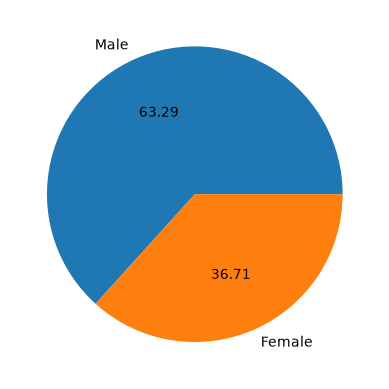

In [8]:
ax = df.loc[df['attrition'] == "Yes", 'gender'].value_counts().plot(kind='pie', autopct='%.2f')
plt.savefig('images/gender_piechart.png', dpi=150, bbox_inches='tight')
plt.show()

**Gender distribution of attrition**

Of employees who left, about 63% were male and 37% were female. This is close to 
the overall company gender split, so gender doesn't appear to be a strong 
standalone driver of attrition.

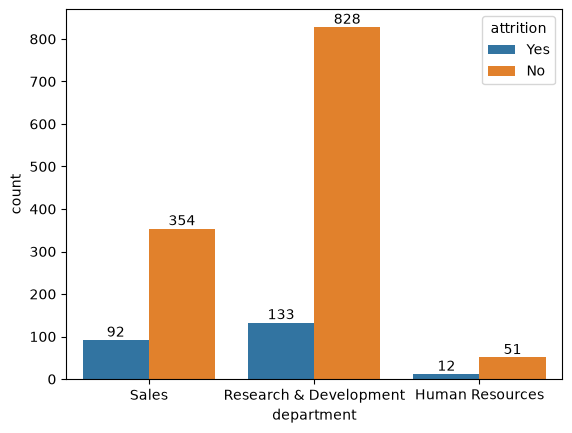

In [9]:
ax = sns.countplot(x='department', hue='attrition', data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.savefig('images/department_attrition_barchart.png', dpi=150, bbox_inches='tight')
plt.show()

**Attrition by department**

Research & Development has the highest attrition count (133), but it also has 
by far the largest headcount. Sales shows a smaller raw count (92) but a much 
higher proportion of its total staff leaving, making it the department with 
the higher relative risk.

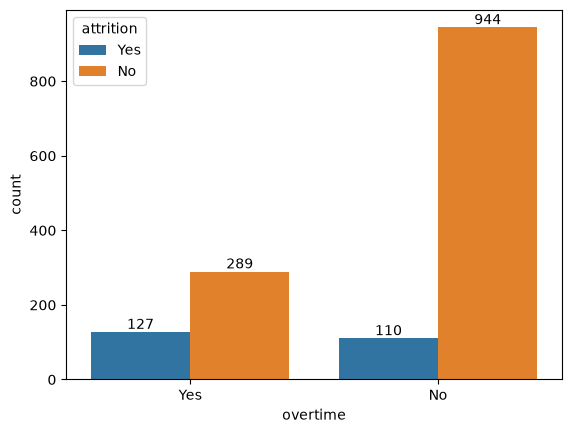

In [10]:
ax = sns.countplot(x='overtime', hue='attrition', data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.savefig('images/overtime_attrition_barchart.png', dpi=150, bbox_inches='tight')
plt.show()

**Attrition by overtime**

Employees who work overtime leave at a much higher rate. 127 out of 416 
overtime workers left (about 30.5%), compared to 110 out of 1054 non-overtime 
workers (about 10.4%). Overtime is the strongest single driver of attrition 
found so far, roughly a 3x difference in rate.

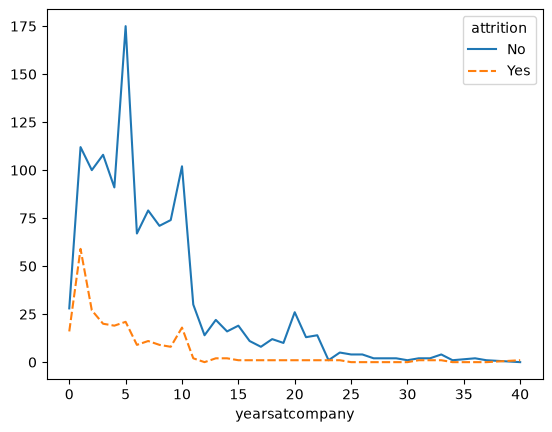

In [11]:
sns.lineplot(data=pd.crosstab(df['yearsatcompany'], df['attrition']))
plt.savefig('images/yearsatcompany_attrition_linechart.png', dpi=150, bbox_inches='tight')
plt.show()

**Attrition by tenure**

Attrition peaks sharply in the first year (59 departures), then drops off as 
tenure increases. This points to an early retention problem, most attrition 
risk is concentrated in an employee's first year, well before the 5 year mark 
where headcount itself peaks.

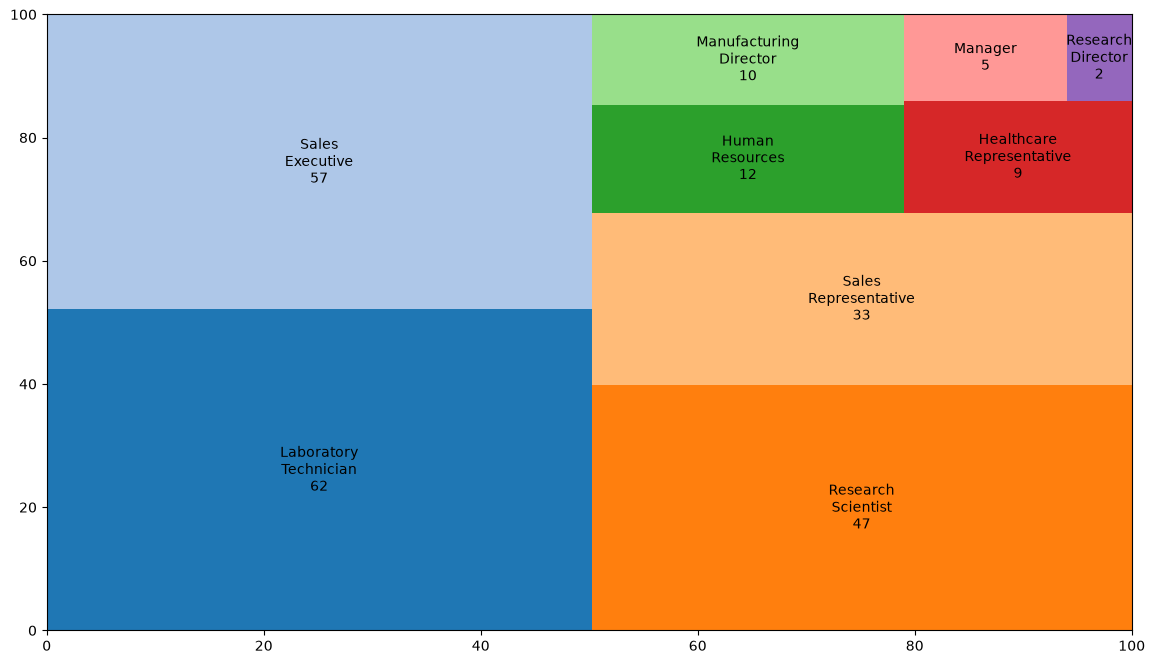

In [12]:
plt.figure(figsize=(14, 8))
counts = df.loc[df['attrition'] == "Yes", 'jobrole'].value_counts()
labels = [f'{role.replace(" ", "\n")}\n{value}' for role, value in zip(counts.index, counts.values)]
ax = sqrf.plot(df.loc[df['attrition'] == "Yes", 'jobrole'].value_counts(),
         label=labels,
         color=sns.color_palette("tab20"),
         text_kwargs={'fontsize': 10})
plt.savefig('images/jobrole_attrition_treemap.png', dpi=150, bbox_inches='tight')

**Attrition by job role**

Laboratory Technician (62) and Sales Executive (57) account for the largest 
share of departures by job role, followed by Research Scientist (47) and 
Sales Representative (33). These four roles alone make up the majority of all 
attrition, suggesting retention efforts could be focused there first.